# Pandas Practice: Bike Share Trip Data

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme — cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../images/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/bike_share_201402_trip_data.csv')
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1 — Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [2]:
# YOUR CODE HERE
df.shape

(144015, 11)

### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [3]:
# # YOUR CODE HERE
# df = df.rename(columns=lambda c: c.replace(' ', '_'))
# df = df.rename(columns=lambda c: c.replace('#', 'num'))
# df = df.rename(columns=lambda c: c.lower)

df.columns

df.rename(columns=lambda c: c.replace(' ', '_'), inplace=True)
df.rename(columns=lambda c: c.lower(), inplace=True)
df.rename(columns=lambda c: c.replace('#', 'num'), inplace=True)

df.columns

Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='str')

---

## Part 2 — Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [4]:
# YOUR CODE HERE
df['subscription_type'].unique()

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [5]:
# YOUR CODE HERE
df.groupby('subscription_type').count()

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,zip_code
subscription_type,,,,,,,,,,
Customer,30368,30368,30368,30368,30368,30368,30368,30368,30368,24238
Subscriber,113647,113647,113647,113647,113647,113647,113647,113647,113647,113647


### Challenge 5: Visualise subscription frequency — pie chart

Plot the frequency of each subscription type as a pie chart.

array([<Axes: >], dtype=object)

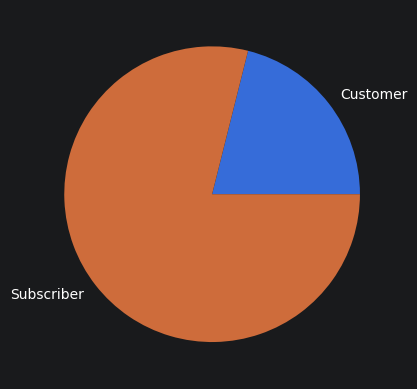

In [6]:
# YOUR CODE HERE
df.groupby('subscription_type')['trip_id'].count().plot(kind='pie', subplots=True)

### Challenge 6: Visualise subscription frequency — bar chart

Plot the same data as a bar chart.

array([<Axes: title={'center': 'trip_id'}, xlabel='subscription_type'>],
      dtype=object)

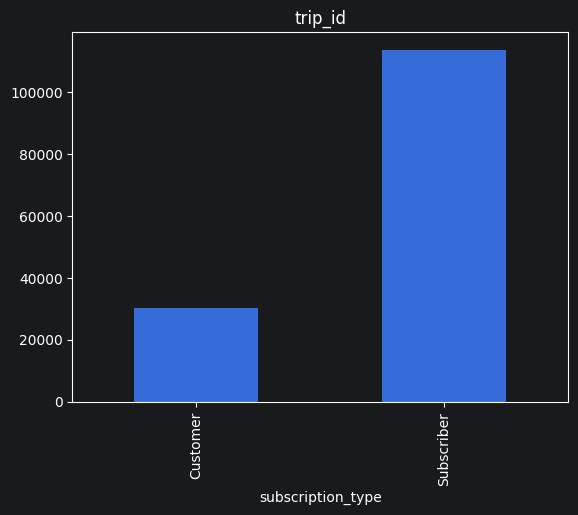

In [7]:
# YOUR CODE HERE
df.groupby('subscription_type')['trip_id'].count().plot(kind='bar', subplots=True)

---

## Part 3 — Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [8]:
# YOUR CODE HERE
df.groupby('start_station')['trip_id'].count().sort_values().tail(10)

start_station
Townsend at 7th                                  4493
Steuart at Market                                4913
San Francisco Caltrain 2 (330 Townsend)          4976
2nd at Townsend                                  4987
Market at 4th                                    5030
Temporary Transbay Terminal (Howard at Beale)    5113
Market at Sansome                                5922
Embarcadero at Sansome                           6545
Harry Bridges Plaza (Ferry Building)             7343
San Francisco Caltrain (Townsend at 4th)         9838
Name: trip_id, dtype: int64

### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [9]:
# YOUR CODE HERE
df.groupby('end_station')['trip_id'].count().sort_values().head(10)

end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
Franklin at Maple                    93
San Antonio Shopping Center          93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: trip_id, dtype: int64

### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [10]:
# YOUR CODE HERE
df.groupby(['start_station', 'subscription_type'])['trip_id'].count()

pd.crosstab(
    df['start_station'],
    df['subscription_type'],
    margins=True
)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


---

## Part 4 — Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [11]:
# YOUR CODE HERE
#df['duration'].sort_values().plot(kind='box', subplots=True, figsize=(5, 10))
df['duration'].describe()
df['duration'].sort_values()
df.groupby('duration')['trip_id'].count()

duration
60        17
61        11
62         9
63        14
64        12
          ..
429384     1
586356     1
597517     1
619322     1
722236     1
Name: trip_id, Length: 7983, dtype: int64

### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

In [12]:
# YOUR CODE HERE
df['duration'].describe()

count    144015.000000
mean       1230.910141
std        6652.962329
min          60.000000
25%         349.000000
50%         531.000000
75%         797.000000
max      722236.000000
Name: duration, dtype: float64

### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

<Axes: ylabel='Frequency'>

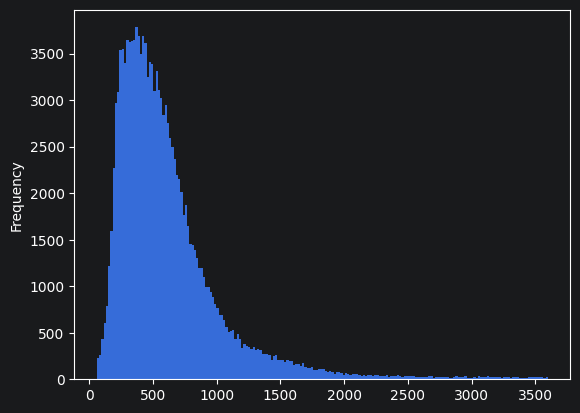

In [13]:
# YOUR CODE HERE
df[df['duration'] < 3600]['duration'].plot(kind='hist', bins=200)

---

## Part 5 — Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead — it will be much faster.

In [16]:
# YOUR CODE HERE
df['start_station'] = df['start_station'].str.lower()
df['start_station'] = df['start_station'].str.replace(' ', '_')

df['end_station'] = df['end_station'].str.lower()
df['end_station'] = df['end_station'].str.replace(' ', '_')

### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data — it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

In [17]:
# YOUR CODE HERE
df

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,south_van_ness_at_market,66,8/29/2013 14:14,south_van_ness_at_market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,san_jose_city_hall,10,8/29/2013 14:43,san_jose_city_hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,mountain_view_city_hall,27,8/29/2013 10:17,mountain_view_city_hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,san_jose_city_hall,10,8/29/2013 11:30,san_jose_city_hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,south_van_ness_at_market,66,8/29/2013 12:04,market_at_10th,67,319,Subscriber,94103
...,...,...,...,...,...,...,...,...,...,...,...
144010,198771,385,2/28/2014 22:15,powell_street_bart,39,2/28/2014 22:22,south_van_ness_at_market,66,483,Subscriber,94404
144011,198772,145,2/28/2014 22:38,commercial_at_montgomery,45,2/28/2014 22:40,davis_at_jackson,42,425,Subscriber,94111
144012,198773,677,2/28/2014 22:45,embarcadero_at_sansome,60,2/28/2014 22:56,market_at_4th,76,438,Subscriber,94102
144013,198774,64128,2/28/2014 23:01,civic_center_bart_(7th_at_market),72,3/1/2014 16:50,harry_bridges_plaza_(ferry_building),50,414,Customer,94124


array([<Axes: title={'center': 'freq'}, xlabel='start_station'>],
      dtype=object)

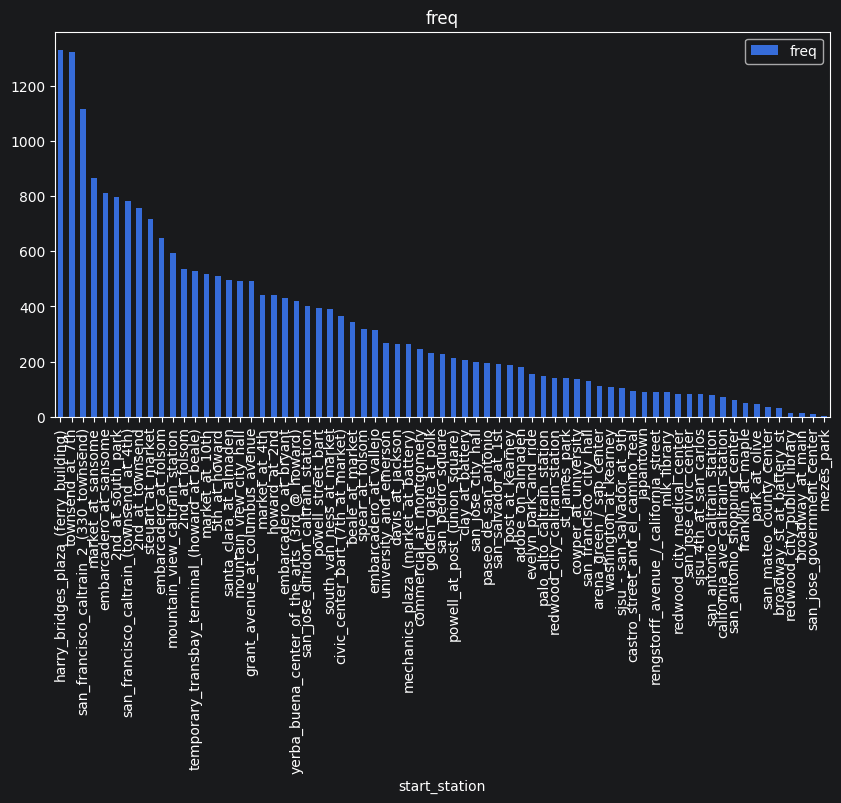

In [44]:
df.groupby('start_station')['end_station'].describe().sort_values(by=['freq'], ascending=False).plot(
    kind='bar',
    subplots=True,
    figsize=(10, 5),
    y=['freq'],
    # xlabel=f'{df["start_station"]} to {df["end_station"]}',
)